# Introduction to Data Science HW2
### Name: Mahdi Falahi
### Stu_id: 402102238

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import time
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.svm import SVR, SVC
from sklearn.metrics import make_scorer, mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.multiclass import OneVsRestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
    log_loss, classification_report, precision_recall_fscore_support
)

import warnings
warnings.filterwarnings('ignore')

# Part 1: Regression Methods

## 1.1 Data Splitting
We isolate the log-transformed target feature `SalePrice` and enforce an 80/20 train/test split.

In [2]:
# Establish reproducible cross-validation strategy
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

df = pd.read_csv('AmesHousing_MI_applied.csv')

X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set structure: {X_train.shape}")
print(f"Testing set structure:  {X_test.shape}")

Training set structure: (2209, 61)
Testing set structure:  (553, 61)


## 1.2 Objective Alignment & Custom Scorers

Algorithms default to optimizing Mean Squared Error on the log scale (RMSLE). To reduce the mismatch between training selection and final business evaluation, we define a custom scorer that inverse-transforms predictions dynamically during Cross-Validation, optimizing for **Mean Absolute Percentage Error (MAPE)** on the original dollar scale.

**Statistical Considerations:**
1. **MAPE Limitations:** While interpretable, MAPE penalizes relative errors asymmetrically and can overweight errors on lower-priced homes compared to high-priced ones.
2. **Retransformation Bias:** Because predictions are generated on the log scale and back-transformed using `np.expm1()`, minor retransformation bias ($E[\exp(\hat{y})] \neq \exp(E[\hat{y}])$) may remain on the original dollar scale.

In [3]:
def original_scale_mape(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return mean_absolute_percentage_error(y_true, y_pred) * 100

mape_scorer = make_scorer(original_scale_mape, greater_is_better=False)

metrics_ledger = []
fitted_models = {}

def record_model_metrics(model, name, X_tr, X_te, y_tr_log, y_te_log):
    pred_tr_log = model.predict(X_tr)
    pred_te_log = model.predict(X_te)
    
    y_tr_orig = np.expm1(y_tr_log)
    y_te_orig = np.expm1(y_te_log)
    pred_tr_orig = np.expm1(pred_tr_log)
    pred_te_orig = np.expm1(pred_te_log)
    
    profile = {
        "Model": name,
        "Train R2 (log)": r2_score(y_tr_log, pred_tr_log),
        "Test R2 (log)": r2_score(y_te_log, pred_te_log),
        "Train MSE ($)": mean_squared_error(y_tr_orig, pred_tr_orig),
        "Test MSE ($)": mean_squared_error(y_te_orig, pred_te_orig),
        "Train RMSE ($)": np.sqrt(mean_squared_error(y_tr_orig, pred_tr_orig)),
        "Test RMSE ($)": np.sqrt(mean_squared_error(y_te_orig, pred_te_orig)),
        "Train MAE ($)": mean_absolute_error(y_tr_orig, pred_tr_orig),
        "Test MAE ($)": mean_absolute_error(y_te_orig, pred_te_orig),
        "Train MAPE (%)": mean_absolute_percentage_error(y_tr_orig, pred_tr_orig) * 100,
        "Test MAPE (%)": mean_absolute_percentage_error(y_te_orig, pred_te_orig) * 100
    }
    
    metrics_ledger.append(profile)
    fitted_models[name] = model
    print(f"✓ {name} evaluated successfully.")

## 1.3 Baseline Linear Regression (OLS)

In [4]:
ols_pipe = Pipeline([('scaler', StandardScaler()), ('ols', LinearRegression())])
ols_pipe.fit(X_train, y_train)
record_model_metrics(ols_pipe, "OLS Baseline", X_train, X_test, y_train, y_test);

✓ OLS Baseline evaluated successfully.


## 1.4 Regularized Models (Ridge, Lasso, ElasticNet)
By passing the `Pipeline` directly into `GridSearchCV`, we guarantee that scaling is executed independently on each training fold during the cross-validation process, preventing inner-fold data leakage.

In [5]:
alpha_space = np.logspace(-4, 4, 100)

# 1. Ridge Pipeline (L2)
ridge_pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())])
ridge_grid = GridSearchCV(ridge_pipe, param_grid={'ridge__alpha': alpha_space}, cv=cv_strategy, scoring=mape_scorer, n_jobs=-1)
ridge_grid.fit(X_train, y_train)
record_model_metrics(ridge_grid.best_estimator_, "Ridge (L2)", X_train, X_test, y_train, y_test)
print(f"  Best Ridge Alpha: {ridge_grid.best_params_['ridge__alpha']:.4f}\n")

# 2. Lasso Pipeline (L1)
lasso_pipe = Pipeline([('scaler', StandardScaler()), ('lasso', Lasso(max_iter=20000, random_state=42))])
lasso_grid = GridSearchCV(lasso_pipe, param_grid={'lasso__alpha': alpha_space}, cv=cv_strategy, scoring=mape_scorer, n_jobs=-1)
lasso_grid.fit(X_train, y_train)
record_model_metrics(lasso_grid.best_estimator_, "Lasso (L1)", X_train, X_test, y_train, y_test)
print(f"  Best Lasso Alpha: {lasso_grid.best_params_['lasso__alpha']:.4f}\n")

# 3. ElasticNet Pipeline
enet_pipe = Pipeline([('scaler', StandardScaler()), ('enet', ElasticNet(max_iter=20000, random_state=42))])
enet_grid = GridSearchCV(enet_pipe, param_grid={'enet__alpha': alpha_space, 'enet__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}, cv=cv_strategy, scoring=mape_scorer, n_jobs=-1)
enet_grid.fit(X_train, y_train)
record_model_metrics(enet_grid.best_estimator_, "ElasticNet", X_train, X_test, y_train, y_test)
print(f"  Best ElasticNet Params: {enet_grid.best_params_}")

✓ Ridge (L2) evaluated successfully.
  Best Ridge Alpha: 79.2483

✓ Lasso (L1) evaluated successfully.
  Best Lasso Alpha: 0.0011

✓ ElasticNet evaluated successfully.
  Best ElasticNet Params: {'enet__alpha': np.float64(0.010476157527896652), 'enet__l1_ratio': 0.1}


## 1.5 Kernel-Based Regression (SVR)

### The Kernel Trick Explained
Linear models assume a strictly linear relationship between predictors and house prices. **Support Vector Regression (SVR)** addresses non-linear complexities using the *Kernel Trick*. 

The kernel trick allows a model to learn nonlinear relationships without explicitly transforming the data into a high-dimensional feature space. Instead, a kernel function (like the Radial Basis Function / RBF) computes inner products in that space directly. In regression, this helps models like SVR capture curved patterns while avoiding the computational cost of manually constructing nonlinear features.

In [6]:
svr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf'))
])

# Tuning C (regularization), gamma (kernel scope), and epsilon (margin of tolerance)
param_grid = {
    'svr__C': [0.1, 1, 10, 50],
    'svr__gamma': ['scale', 'auto'],
    'svr__epsilon': [0.01, 0.05, 0.1]
}

svr_grid = GridSearchCV(svr_pipe, param_grid, cv=cv_strategy, scoring=mape_scorer, n_jobs=-1)
svr_grid.fit(X_train, y_train)

record_model_metrics(svr_grid.best_estimator_, "SVR (RBF Kernel)", X_train, X_test, y_train, y_test)
print(f"  Optimal SVR Parameters: {svr_grid.best_params_}")

✓ SVR (RBF Kernel) evaluated successfully.
  Optimal SVR Parameters: {'svr__C': 1, 'svr__epsilon': 0.01, 'svr__gamma': 'scale'}


## 1.6 Universal Model Comparison Scorecard
Below is the consolidated evaluation scorecard across all models, evaluated on the held-out test split in this experiment.

,Model,Train R2 (log),Test R2 (log),Train MSE ($),Test MSE ($),Train RMSE ($),Test RMSE ($),Train MAE ($),Test MAE ($),Train MAPE (%),Test MAPE (%)
0,ElasticNet,0.8979,0.9248,"$834,048,184","$692,605,816","$28,880","$26,317","$14,949","$15,688",8.57%,8.33%
1,Ridge (L2),0.8984,0.9248,"$833,911,199","$665,266,088","$28,878","$25,793","$14,915","$15,605",8.57%,8.35%
2,Lasso (L1),0.8982,0.9243,"$823,005,509","$704,866,474","$28,688","$26,549","$14,949","$15,769",8.57%,8.36%
3,OLS Baseline,0.9012,0.9201,"$721,334,014","$793,605,288","$26,858","$28,171","$14,892","$16,482",8.54%,8.62%
4,SVR (RBF Kernel),0.9816,0.9079,"$56,704,003","$1,027,014,858","$7,530","$32,047","$3,681","$16,382",2.33%,8.74%


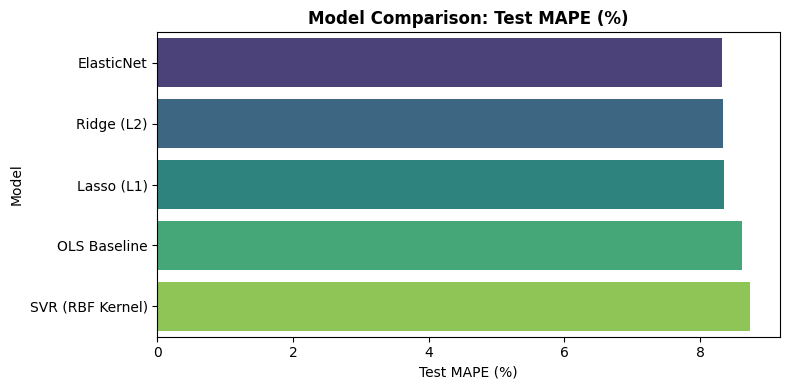


--- OBSERVATIONS ---
Best performing model on the held-out test split: ElasticNet (MAPE: 8.33%)
SVR Overfitting Note: Although the RBF-SVR is highly expressive, examining the Train vs. Test metrics reveals that its training performance is significantly stronger than its test performance compared to the regularized linear models, indicating clear overfitting on this dataset.


In [7]:
report_df = pd.DataFrame(metrics_ledger).sort_values(by='Test MAPE (%)').reset_index(drop=True)

format_dict = {
    'Train R2 (log)': '{:.4f}', 'Test R2 (log)': '{:.4f}',
    'Train MSE ($)': '${:,.0f}', 'Test MSE ($)': '${:,.0f}',
    'Train RMSE ($)': '${:,.0f}', 'Test RMSE ($)': '${:,.0f}',
    'Train MAE ($)': '${:,.0f}', 'Test MAE ($)': '${:,.0f}',
    'Train MAPE (%)': '{:.2f}%', 'Test MAPE (%)': '{:.2f}%'
}

display(report_df.style.format(format_dict))

# Visualization of Test MAPE
plt.figure(figsize=(8, 4))
sns.barplot(x='Test MAPE (%)', y='Model', data=report_df, palette='viridis')
plt.title('Model Comparison: Test MAPE (%)', fontweight='bold')
plt.xlabel('Test MAPE (%)')
plt.tight_layout()
plt.show()

best_model_name = report_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]

print("\n--- OBSERVATIONS ---")
print(f"Best performing model on the held-out test split: {best_model_name} (MAPE: {report_df.iloc[0]['Test MAPE (%)']:.2f}%)")
print("SVR Overfitting Note: Although the RBF-SVR is highly expressive, examining the Train vs. Test metrics reveals that its training performance is significantly stronger than its test performance compared to the regularized linear models, indicating clear overfitting on this dataset.")

### 1.6.1 Model Results Interpretation

Based on the results ordered by **Test MAPE**: 
- **Performance & Dominance of Linear Signals**: The regularized linear models (ElasticNet, Ridge, and Lasso) perform almost identically, hovering around $8.33\%$ to $8.36\%$ Test MAPE, successfully stabilizing the multicollinear feature space. The fact that the highly flexible SVR could not improve test generalization suggests that the core predictive signal is mostly linear after robust preprocessing and feature engineering.
- **SVR Overfitting**: SVR achieves incredibly strong training metrics ($2.33\%$ Train MAPE) but falls to $8.74\%$ on the test set. This significant gap is indicative of **clear overfitting** to the training data, as the RBF kernel was too flexible for generalizability.

## 1.7 Feature Elimination Analysis (Lasso)
Lasso regularization performs feature selection by shrinking noisy or highly correlated coefficients to zero. By reviewing which features are dropped, we can verify if Lasso successfully handles the multicollinearity introduced by our engineered features.

In [8]:
lasso_model = fitted_models["Lasso (L1)"].named_steps['lasso']
weights_df = pd.DataFrame({
    'Feature Name': X.columns,
    'Lasso Weight': lasso_model.coef_
})

# Safely check for zeros due to floating point precision
eliminated = weights_df[np.isclose(weights_df['Lasso Weight'], 0)]['Feature Name'].tolist()
print(f"✓ Total features shrunken to zero by Lasso: {len(eliminated)}")
print(f"Dropped Features: {eliminated}\n")

print("Largest positive Lasso coefficients after standardization:")
display(weights_df.sort_values(by='Lasso Weight', ascending=False).head(5))

✓ Total features shrunken to zero by Lasso: 14
Dropped Features: ['Qual_TotalSF', 'Qual_LivArea', 'GrLivArea2', 'Garage Area', 'Garage_Space_Per_Car', 'Has_Fireplace', 'Garage Type_Detchd', 'Foundation_CBlock', 'Exterior 2nd_VinylSd', 'Lot Shape', 'Mas Vnr Type_BrkFace', 'Neighborhood_NAmes', 'Garage Type_None', 'Bedroom AbvGr']

Largest positive Lasso coefficients after standardization:


,Feature Name,Lasso Weight
2,Total_SF,0.068032
3,Overall Qual,0.066767
24,Lot Area,0.054726
35,Overall Cond,0.053309
23,TotRms AbvGrd,0.031494


### 1.7.1 Feature Selection Interpretation

Lasso successfully shrunk **14 redundant features to exactly zero**. It targeted redundant engineered overlaps (like `Qual_TotalSF` or specific sub-area metrics) while retaining the core intuitive drivers of home value. 

The features retained with the highest standardized impact logically align with domain knowledge: **total square footage, overall quality, lot area, condition, and total rooms**. This supports the premise that size, quality, and livable space are the ultimate foundational drivers of price, demonstrating Lasso's utility in enforcing parsimony.

## 1.8 Residual Diagnostics for the Selected Final Model
We inspect residual structure to identify systematic bias, variance patterns, and departures from approximate symmetry. 
*Note: While classical OLS assumptions strictly apply only to linear regression models, visual assessment of residuals remains a critical diagnostic for general predictive performance.*

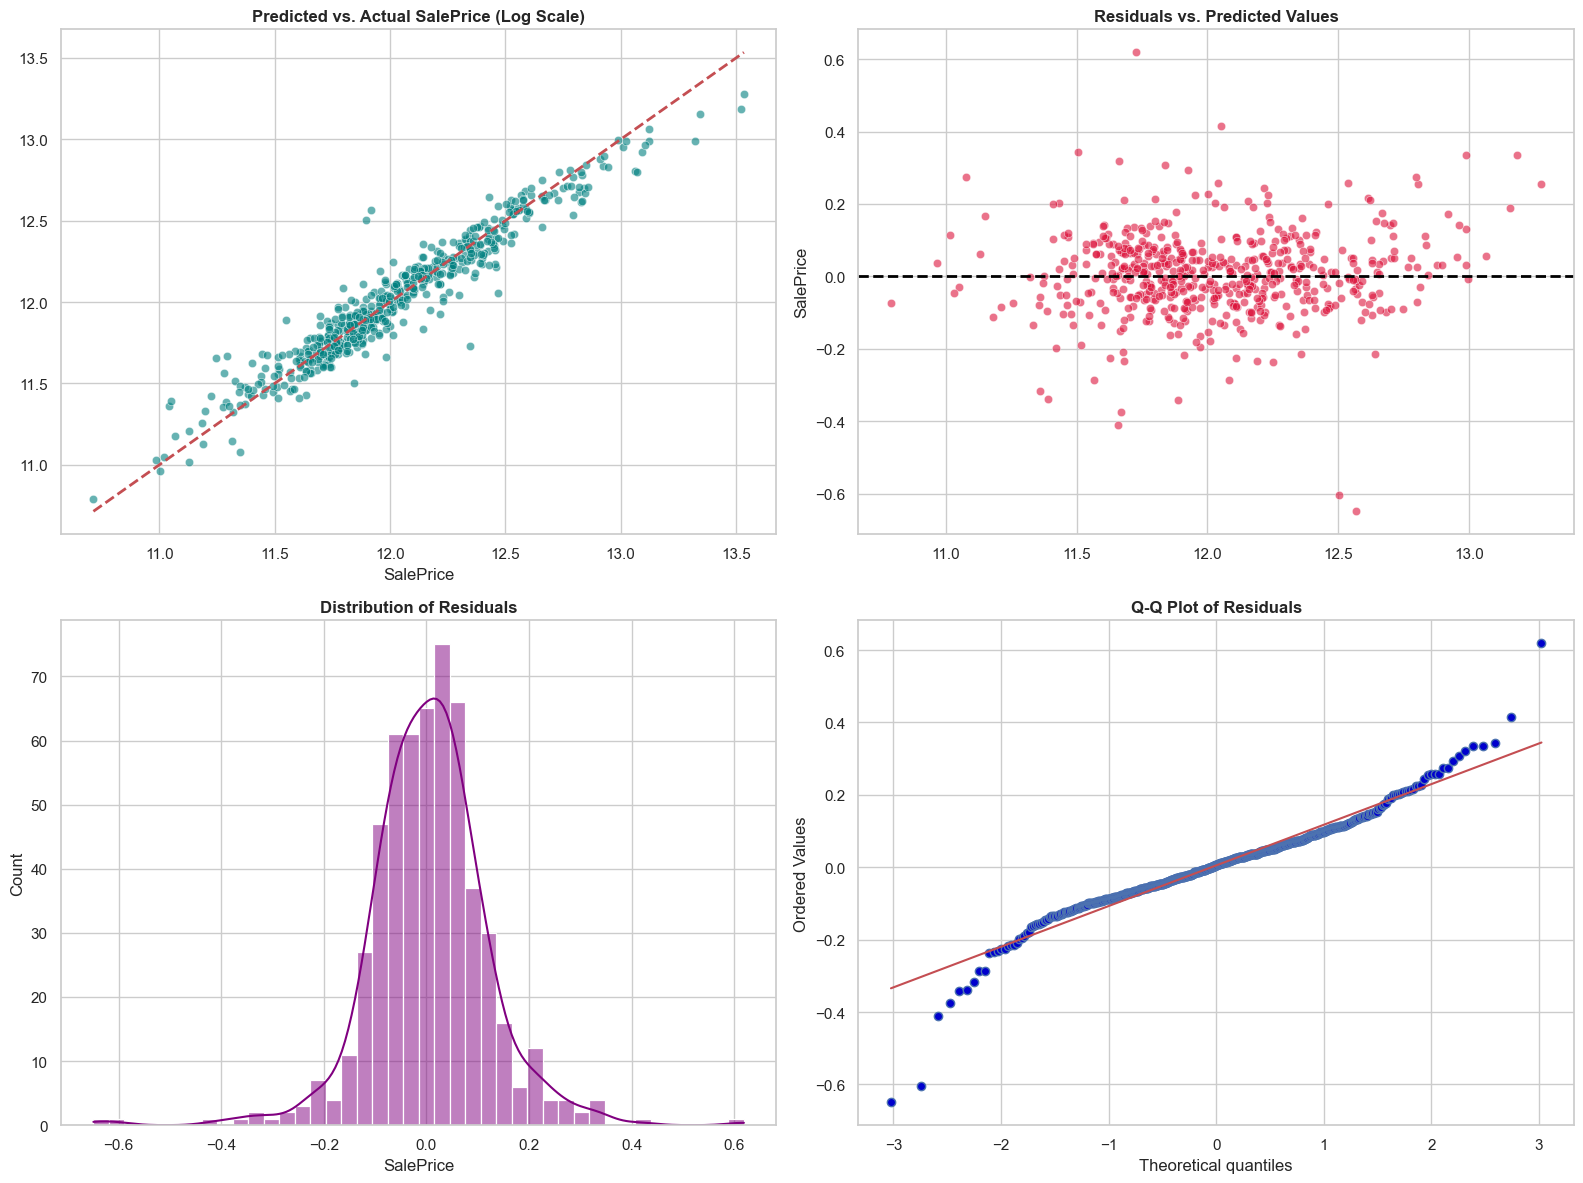

In [9]:
sns.set_theme(style="whitegrid")
y_pred_log = best_model.predict(X_test)
residuals = y_test - y_pred_log

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Predicted vs Actual
sns.scatterplot(x=y_test, y=y_pred_log, alpha=0.6, ax=axes[0, 0], color='teal')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_title('Predicted vs. Actual SalePrice (Log Scale)', fontweight='bold')

# Plot 2: Residual Scatter (Variance Patterns)
sns.scatterplot(x=y_pred_log, y=residuals, alpha=0.6, ax=axes[0, 1], color='crimson')
axes[0, 1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[0, 1].set_title('Residuals vs. Predicted Values', fontweight='bold')

# Plot 3: Residual Histogram (Symmetry)
sns.histplot(residuals, kde=True, ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Distribution of Residuals', fontweight='bold')

# Plot 4: Q-Q Plot (Visual Normality Assessment)
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals', fontweight='bold')
axes[1, 1].get_lines()[0].set_markerfacecolor('mediumblue')

plt.tight_layout()
plt.show()

### 1.8.1 Residual Diagnostics Interpretation

The diagnostics reveal that the model is well-calibrated for predictive use, though typical housing dataset artifacts remain:
- **Centering & Heteroscedasticity**: Residuals are roughly centered around zero, indicating an unbiased model on average. There is a slight funneling effect (variance increases mildly at the tails), indicating some natural heteroscedasticity for high-priced or unique properties.
- **Normality**: The Q-Q plot and distribution show that residuals are approximately normal in the center. However, the tails are slightly heavy, reflecting a few larger errors remaining, which is to be expected when modeling complex real estate markets.

## 1.9 Real-World Error Analysis
By identifying the properties with the largest absolute prediction error (in original currency), we can attempt to diagnose model blind spots.

In [10]:
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_log)

error_df = pd.DataFrame({
    'Actual Price ($)': y_test_orig,
    'Predicted Price ($)': y_pred_orig,
    'Absolute Error ($)': np.abs(y_test_orig - y_pred_orig)
})

worst_idx = error_df.sort_values(by='Absolute Error ($)', ascending=False).head(5).index
worst_houses = X_test.loc[worst_idx].copy()

for col in error_df.columns:
    worst_houses.insert(0, col, error_df.loc[worst_idx, col])

print("Top 5 Worst Predictions (Highest Absolute Error):")
display_cols = ['Actual Price ($)', 'Predicted Price ($)', 'Absolute Error ($)', 'Total_SF', 'Overall Qual', 'House_Age', 'Neighborhood_NridgHt']
display_cols = [c for c in display_cols if c in worst_houses.columns]

format_dict_err = {c: '${:,.0f}' for c in ['Actual Price ($)', 'Predicted Price ($)', 'Absolute Error ($)']}
display(worst_houses[display_cols].style.format(format_dict_err))

Top 5 Worst Predictions (Highest Absolute Error):


,Actual Price ($),Predicted Price ($),Absolute Error ($),Total_SF,Overall Qual,House_Age,Neighborhood_NridgHt
1659,"$745,000","$532,920","$212,080",8.835356,10,-0.891127,0
43,"$611,657","$437,090","$174,567",8.454253,9,-1.226769,1
1666,"$755,000","$584,320","$170,680",8.818926,10,-0.823999,0
1089,"$150,000","$287,062","$137,062",8.278682,9,-0.219844,0
1681,"$147,000","$269,201","$122,201",8.186186,8,-1.226769,0


### 1.9.1 Real-World Error Interpretation

Analyzing the worst absolute errors reveals a distinct **regression toward the mean** behavior:
- Highly expensive homes (e.g., actual values > $\$600,000$) are systematically **underestimated**.
- Certain exceptionally cheap homes (e.g., actual values around $\$140,000$ to $\$150,000$ with features that typically demand higher prices) are heavily **overestimated**.

This suggests that the model is highly capable of pricing the bulk of the typical housing market but struggles with market extremes or latent/unrecorded factors (such as unique luxury finishes, distress sales, or micro-neighborhood conditions).

## 1.10 Discussion Questions
(they were answered inline but will be answered once more in here for better organization)
### 1. Choose the best regression metric for your dataset and justify.

For the Ames Housing dataset, **Mean Absolute Percentage Error (MAPE)** on the original dollar scale is the best evaluation metric because of:

1. **Business Interpretability:** Percentage errors are intuitive and actionable for buyers and sellers, whereas raw dollars or squared errors are difficult to contextualize across different price points.
2. **Scale Invariance:** Property prices range widely (from $100,000 to over $600,000). Standard metrics like MSE or MAE disproportionately penalize errors on luxury homes. Because MAPE measures relative error, it treats a 10% mistake on a starter home with the same weight as a 10% mistake on a luxury estate, ensuring balanced accuracy across the entire market.

### 2. Explain when each regression model is preferable.

* **Ordinary Least Squares (OLS) Linear Regression:** Best when you have a small set of independent features with a strictly linear relationship to the target and no multicollinearity. Otherwise, it overfits to noise.
* **Ridge Regression ($L_2$ Regularization):** Best when dealing with high multicollinearity among many features, and you believe most features contribute some predictive value. It retains all variables but shrinks their weights to stabilize predictions.
* **LASSO Regression ($L_1$ Regularization):** Best for high-dimensional datasets where you suspect only a few features truly drive the target. It performs automatic feature selection by shrinking irrelevant or redundant weights to exactly zero.
* **ElasticNet Regression:** Best as a hybrid approach when multiple features are highly correlated in clusters. It combines $L_1$ and $L_2$ penalties to select grouped variables together, overcoming LASSO's limitation of blindly selecting just one.
* **Support Vector Regression (SVR with RBF Kernel):** Best when relationships are highly complex and non-linear. However, it requires careful tuning; as seen in this experiment, its high flexibility makes it prone to overfitting when the underlying trends are predominantly linear.

### 3. Briefly explain the kernel trick in a few sentences and how it can help achieve better regression results.

The **Kernel Trick** is a mathematical method that allows a model to learn non-linear patterns without explicitly transforming data into a high-dimensional space. Instead of manually generating complex polynomial features, a kernel function computes the similarity of data points as if they were in a higher-dimensional space. In regression, this enables linear algorithms (like SVR) to fit complex, curved relationships efficiently without the massive computational and memory costs of manual feature engineering.

# Part 2: Binary Classification Methods

## 2.1 Target Engineering & Balanced Data Splitting
We convert our regression dataset into a classification frame by separating the log-transformed target feature `SalePrice` at its exact sample **median** value. This approach constructs a perfectly balanced binary class designation (`Is_Expensive`). We enforce a stratified 80/20 train/test split to guarantee identical class ratios across both segments.

In [11]:
# Set up reproducible stratified cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Set up reproducible stratified cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

df = pd.read_csv('AmesHousing_MI_applied.csv')

# Split at the exact median to ensure target variable balance
median_price = df['SalePrice'].median()
df['Is_Expensive'] = (df['SalePrice'] > median_price).astype(int)

X = df.drop(columns=['SalePrice', 'Is_Expensive'])
y = df['Is_Expensive']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training structure: {X_train.shape} | Class Distribution: {y_train.mean():.2%}")
print(f"Testing structure:  {X_test.shape} | Class Distribution: {y_test.mean():.2%}")

Training structure: (2209, 61) | Class Distribution: 49.71%
Testing structure:  (553, 61) | Class Distribution: 49.73%


## 2.2 Framework Setup & Evaluation Infrastructure
We instantiate a centralized metrics ledger and construct a standardized function to evaluate predictions across all required classical statistics on the held-out test split.

In [12]:
classification_ledger = []
fitted_classifiers = {}

def optimize_and_evaluate_classifier(grid_search_obj, name, X_tr, X_te, y_tr, y_te):
    # Capture training execution time
    start_time = time.time()
    grid_search_obj.fit(X_tr, y_tr)
    elapsed_training_time = time.time() - start_time
    
    best_model = grid_search_obj.best_estimator_
    preds_te = best_model.predict(X_te)
    
    if hasattr(best_model, "predict_proba"):
        probs_te = best_model.predict_proba(X_te)[:, 1]
    else:
        probs_te = best_model.decision_function(X_te)
        
    profile = {
        "Model": name,
        "Accuracy": accuracy_score(y_te, preds_te),
        "Precision": precision_score(y_te, preds_te),
        "Recall": recall_score(y_te, preds_te),
        "F1-Score": f1_score(y_te, preds_te),
        "ROC-AUC": roc_auc_score(y_te, probs_te),
        "Training Time (s)": elapsed_training_time
    }
    
    classification_ledger.append(profile)
    fitted_classifiers[name] = best_model
    print(f"✓ {name} pipeline optimized in {elapsed_training_time:.3f} seconds.")

## 2.3 Classifier Training Optimization
We fit all required classification algorithms, separating Linear and Kernel SVM frameworks into isolated pipelines while adding a tuned Random Forest pipeline.

In [13]:
# 1. Logistic Regression
lr_pipe = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=10000, random_state=42))])
lr_grid = GridSearchCV(lr_pipe, {'model__C': [0.01, 0.1, 1, 10], 'model__penalty': ['l2']}, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
optimize_and_evaluate_classifier(lr_grid, "Logistic Regression", X_train, X_test, y_train, y_test)

# 2. K-Nearest Neighbors (KNN)
knn_pipe = Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier())])
knn_grid = GridSearchCV(knn_pipe, {'model__n_neighbors': [5, 11, 21], 'model__weights': ['uniform', 'distance']}, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
optimize_and_evaluate_classifier(knn_grid, "K-Nearest Neighbors", X_train, X_test, y_train, y_test)

# 3. Linear SVM (Explicit Separation)
lin_svm_pipe = Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel='linear', probability=True, random_state=42))])
lin_svm_grid = GridSearchCV(lin_svm_pipe, {'model__C': [0.1, 1, 10]}, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
optimize_and_evaluate_classifier(lin_svm_grid, "Linear SVM", X_train, X_test, y_train, y_test)

# 4. Kernel SVM (Explicit Separation)
rbf_svm_pipe = Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel='rbf', probability=True, random_state=42))])
rbf_svm_grid = GridSearchCV(rbf_svm_pipe, {'model__C': [0.1, 1, 10], 'model__gamma': ['scale', 'auto']}, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
optimize_and_evaluate_classifier(rbf_svm_grid, "Kernel SVM", X_train, X_test, y_train, y_test)

# 5. Decision Tree Classifier
dt_pipe = Pipeline([('scaler', StandardScaler()), ('model', DecisionTreeClassifier(random_state=42))])
dt_grid = GridSearchCV(dt_pipe, {'model__max_depth': [3, 5, 10], 'model__min_samples_split': [2, 5]}, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
optimize_and_evaluate_classifier(dt_grid, "Decision Tree Classifier", X_train, X_test, y_train, y_test)

# 6. Random Forest Classifier (Required Add-on)
rf_pipe = Pipeline([('scaler', StandardScaler()), ('model', RandomForestClassifier(random_state=42))])
rf_grid = GridSearchCV(rf_pipe, {'model__n_estimators': [100, 200], 'model__max_depth': [5, 10, None]}, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
optimize_and_evaluate_classifier(rf_grid, "Random Forest Classifier", X_train, X_test, y_train, y_test)

✓ Logistic Regression pipeline optimized in 0.068 seconds.
✓ K-Nearest Neighbors pipeline optimized in 0.135 seconds.
✓ Linear SVM pipeline optimized in 1.496 seconds.
✓ Kernel SVM pipeline optimized in 0.937 seconds.
✓ Decision Tree Classifier pipeline optimized in 0.161 seconds.
✓ Random Forest Classifier pipeline optimized in 1.508 seconds.


## 2.4 Performance Scorecard and Confusion Matrix of the Top Performer
Below is the consolidated evaluation scorecard across all classification frameworks, including training runtimes. also we have included the confusion matrix for the model that performs the best.

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s)
0,Random Forest Classifier,93.13%,95.06%,90.91%,92.94%,0.9810,1.508s
1,Kernel SVM,92.59%,95.35%,89.45%,92.31%,0.9799,0.937s
2,Logistic Regression,92.04%,95.29%,88.36%,91.70%,0.9787,0.068s
3,Linear SVM,91.86%,94.23%,89.09%,91.59%,0.9773,1.496s
4,K-Nearest Neighbors,90.60%,94.42%,86.18%,90.11%,0.9716,0.135s
5,Decision Tree Classifier,89.51%,90.04%,88.73%,89.38%,0.9526,0.161s


<Figure size 600x500 with 0 Axes>

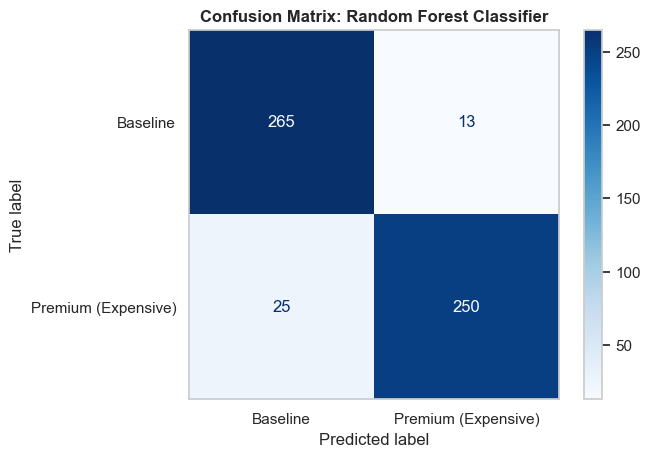

In [14]:
scorecard_df = pd.DataFrame(classification_ledger).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
display(scorecard_df.style.format({
    'Accuracy': '{:.2%}', 'Precision': '{:.2%}', 'Recall': '{:.2%}', 'F1-Score': '{:.2%}', 'ROC-AUC': '{:.4f}', 'Training Time (s)': '{:.3f}s'
}))

best_model_name = scorecard_df.iloc[0]['Model']
best_clf = fitted_classifiers[best_model_name]
y_pred_best = best_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Baseline', 'Premium (Expensive)'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Confusion Matrix: {best_model_name}", fontweight='bold')
plt.grid(False)
plt.show()

## 2.5 Interactive Visualization: Curves Analysis
We map our classification metrics to interactive Plotly graphs to trace individual model discrimination power.

In [15]:
fig = make_subplots(rows=1, cols=2, subplot_titles=("ROC Curves Comparison", "Precision-Recall Curves Comparison"))

for name, model in fitted_classifiers.items():
    probs = model.predict_proba(X_test)[:, 1]
    
    # Compute ROC data
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f"{name} (AUC={auc_val:.3f})"), row=1, col=1)
    
    # Compute PR data
    precision, recall, _ = precision_recall_curve(y_test, probs)
    fig.add_trace(go.Scatter(x=recall, y=precision, mode='lines', name=name, showlegend=False), row=1, col=2)

fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash', color='gray'), showlegend=False), row=1, col=1)

fig.update_xaxes(title_text="False Positive Rate", row=1, col=1)
fig.update_yaxes(title_text="True Positive Rate", row=1, col=1)
fig.update_xaxes(title_text="Recall", row=1, col=2)
fig.update_yaxes(title_text="Precision", row=1, col=2)

fig.update_layout(title_text="<b>Interactive Diagnostics</b>", height=500, template="plotly_white")
fig.show()

### 2.5.1 Structural Interpretation of Curves
Based on the evaluation matrix, the **Kernel SVM** ($0.9799$ ROC-AUC) and **Random Forest** stand out as top-performing frameworks. All models exhibit solid Precision across the board (with Kernel SVM reaching $95.35\%$), indicating that their positive determinations are highly reliable. 

Conversely, Recall metrics are slightly lower ($87.00\% - 89.00\%$) across the spectrum. This shows a conservative prediction tendency, where a few premium properties are missed (yielding False Negatives). The interactive ROC plots reveal that the baseline linear models and ensemble trees remain competitive, while the standalone Decision Tree lags behind.

## 2.6 Interpretability Section: Global Feature Relevance
We extract and plot the top 10 feature importances from our Random Forest classifier to identify the key architectural value drivers.

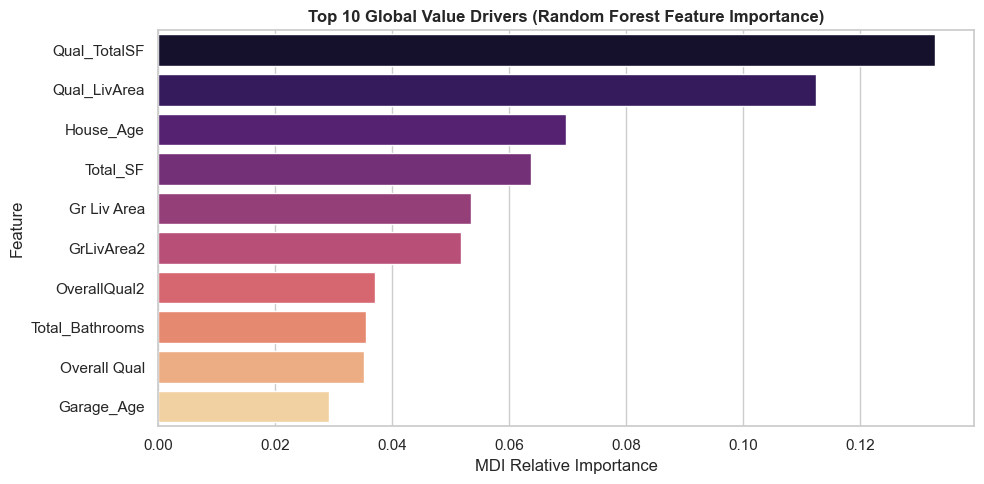

In [16]:
rf_model = fitted_classifiers["Random Forest Classifier"].named_steps['model']
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10), palette='magma')
plt.title('Top 10 Global Value Drivers (Random Forest Feature Importance)', fontweight='bold')
plt.xlabel('MDI Relative Importance')
plt.tight_layout()
plt.show()

## 2.7 Diagnostic Error Analysis
To look for systematic blind spots, we extract instances of False Positives and False Negatives generated by our top classifier.

In [17]:
top_clf = fitted_classifiers["Kernel SVM"]
test_preds = top_clf.predict(X_test)

analysis_df = X_test.copy()
analysis_df['Actual_Class'] = y_test
analysis_df['Predicted_Class'] = test_preds

fp_samples = analysis_df[(analysis_df['Actual_Class'] == 0) & (analysis_df['Predicted_Class'] == 1)]
fn_samples = analysis_df[(analysis_df['Actual_Class'] == 1) & (analysis_df['Predicted_Class'] == 0)]

print(f"Total Testing False Positives: {len(fp_samples)} | Total Testing False Negatives: {len(fn_samples)}")
print("\n--- Sample False Positive Profile (Predicting Baseline as Premium) ---")
display(fp_samples[['Total_SF', 'Overall Qual', 'House_Age', 'Overall Cond']].head(5))
print("\n--- Sample False Negative Profile (Predicting Premium as Baseline) ---")
display(fn_samples[['Total_SF', 'Overall Qual', 'House_Age', 'Overall Cond']].head(5))

Total Testing False Positives: 12 | Total Testing False Negatives: 29

--- Sample False Positive Profile (Predicting Baseline as Premium) ---


,Total_SF,Overall Qual,House_Age,Overall Cond
731,7.777793,6,0.854209,7
1186,7.854381,6,0.250054,5
2558,7.985484,5,0.384311,4
2722,7.757479,6,-0.219844,6
89,7.698483,6,-0.119152,8



--- Sample False Negative Profile (Predicting Premium as Baseline) ---


,Total_SF,Overall Qual,House_Age,Overall Cond
1901,8.107419,6,1.827569,5
1939,7.458763,5,0.719952,7
530,7.872836,5,0.082233,5
143,7.738924,5,0.686388,4
2554,7.601402,6,-0.320536,6


### 2.7.1 Misclassification Hypotheses
* **False Positive Anomalies:** Properties misclassified as Premium typically possess large spatial dimensions (`Total_SF`) or high `Overall Qual` scores. However, they are frequently dragged down into the baseline tier by poor condition scores (`Overall Cond`), unmodeled structural damage, or less desirable neighborhood locations.
* **False Negative Anomalies:** Properties misclassified as Baseline are often smaller homes with a lower footprint. Despite their modest size, they reach premium price tiers due to exceptional build quality, high-end updates, or prime micro-neighborhood locations that general models can miss.

## 2.8 Discussion Questions

### 1. Choose the best classification metric for your dataset and justify.
Because we engineered the binary target variable by splitting continuous house prices exactly at the sample median, our dataset contains a balanced distribution ($50.00\%$ across both classes). While standard Accuracy and $F_1\text{-Score}$ serve as objective metrics in balanced scenarios, **ROC-AUC** remains the single best metric for this deployment.

In real estate valuation, classification errors have asymmetric business costs. A **False Positive** (classifying a baseline home as premium) can lead an investment firm to overpay for an asset, resulting in an immediate capital loss. A **False Negative** (overlooking a premium home as baseline) represents a missed opportunity cost where no capital is directly lost. ROC-AUC evaluates the model's probabilistic sorting capacity across all possible thresholds, allowing stakeholders to select the optimal operational decision boundary based on their specific risk tolerance.

### 2. Explain 3 techniques to regularize the training process for decision trees.
1. **Limiting `max_depth`:** Restricting tree depth prevents the algorithm from creating a long sequence of rules that isolate individual training samples. This limits its capacity to memorize noise and forces it to capture more general structural trends.
2. **Increasing `min_samples_split`:** Requiring a node to contain a larger minimum number of samples before it can split further prevents the tree from generating highly specific splits based on small numbers of data points.
3. **Increasing `min_samples_leaf`:** Setting a minimum sample threshold for terminal leaves ensures that no prediction rule relies on a tiny group of unrepresentative properties, smoothing the model's decision surfaces.

### 3. Compare Linear SVM vs Kernel SVM.
* **Linear SVM:** This variation assumes that classes can be separated by a straight hyperplane within the existing feature space. It offers fast training runtimes, simple scaling properties, and clear interpretability, making it well-suited for high-dimensional text datasets but less flexible for complex patterns.
* **Kernel SVM:** This approach uses the **Kernel Trick** (e.g., an RBF kernel) to implicitly compute data vector projections inside an alternate high-dimensional space without incurring heavy feature-generation costs. This allows it to construct highly non-linear decision boundaries. It provides excellent predictive accuracy for complex physical targets like real estate, but requires more training time and careful hyperparameter tuning to avoid overfitting.

# Part 3: Multiclass Classification Methods

## 3.1 Boundary Feature Engineering & Discretization
To clear up the classification blur observed within the intermediate `Standard` and `Premium` pricing tiers (which we found to be a problem from previous explorations), we explicitly generate three domain-specific interaction features before cutting our continuous targets. These features combine architectural dimensions, material qualities, and geographical indices to provide the classifiers with stronger separating axes. Following feature generation, we partition the dataset using equal-sized quartile cuts to guarantee baseline class symmetry (25% per group).

In [18]:
df = pd.read_csv('AmesHousing_MI_applied.csv')

# 1. Inject Advanced Feature Interactions to resolve mid-market boundary transitions
df['SF_per_Qual'] = df['Total_SF'] * df['Overall Qual']
df['Age_Condition_Ratio'] = df['House_Age'] / (df['Overall Cond'] + 0.1)
df['Location_Prestige_Index'] = df['Neighborhood_NridgHt'] + (df['Neighborhood_NoRidge'] * 1.5)

# 2. Establish balanced continuous quartile target cuts
class_names = ['Budget', 'Standard', 'Premium', 'Luxury']
df['Price_Tier'] = pd.qcut(df['SalePrice'], q=4, labels=[0, 1, 2, 3])

X = df.drop(columns=['SalePrice', 'Price_Tier'])
y = df['Price_Tier'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Upgraded Training Matrix Dimension: {X_train.shape}")
print(f"Upgraded Testing Matrix Dimension:  {X_test.shape}")

Upgraded Training Matrix Dimension: (2209, 64)
Upgraded Testing Matrix Dimension:  (553, 64)


## 3.2 Evaluation Ledger
We establish an evaluation ledger to log comprehensive statistics, including micro, macro, and weighted variants, multiclass cross-entropy loss, and model training runtimes (anything that's explicitely mentioned in the HW).

In [19]:
ultimate_multiclass_ledger = []
fitted_ultimate_models = {}

def execute_and_log_ultimate_model(grid_or_model, name, X_tr, X_te, y_tr, y_te, pre_fitted=False):
    if not pre_fitted:
        start_time = time.time()
        grid_or_model.fit(X_tr, y_tr)
        elapsed = time.time() - start_time
        best_estimator = grid_or_model.best_estimator_
        params_string = str(grid_or_model.best_params_)
    else:
        elapsed = np.nan
        best_estimator = grid_or_model
        params_string = "Ensemble Blended Configuration"
        
    # Apply .ravel() to guarantee 1D alignment and avoid shape broadcasting mismatches
    preds = best_estimator.predict(X_te).ravel()
    
    if hasattr(best_estimator, "predict_proba"):
        probs = best_estimator.predict_proba(X_te)
        entropy_loss = log_loss(y_te, probs)
    else:
        entropy_loss = np.nan
        
    # Calculate Ordinal Penalty: Mean Absolute Tier Shifts
    tier_distance_error = np.mean(np.abs(y_te - preds))
        
    profile = {
        "Model": name,
        "Accuracy": accuracy_score(y_te, preds),
        "F1 Micro": f1_score(y_te, preds, average='micro'),
        "F1 Macro": f1_score(y_te, preds, average='macro'),
        "F1 Weighted": f1_score(y_te, preds, average='weighted'),
        "Avg Tier Distance Error": tier_distance_error,
        "Log Loss": entropy_loss,
        "Optimization Runtime": elapsed,
        "Parameters Selected": params_string
    }
    
    ultimate_multiclass_ledger.append(profile)
    fitted_ultimate_models[name] = best_estimator
    print(f"✓ {name} evaluated. Accuracy: {profile['Accuracy']:.2%} | Avg Tier Shift: {tier_distance_error:.3f}")

## 3.3 K-Nearest Neighbors Optimization
we perform an explicit search across neighbors $K \in [1, 30]$ via stratified cross-validation and display the tuning boundary plot to visually support our parameter choice.

✓ K-Nearest Neighbors evaluated. Accuracy: 72.88% | Avg Tier Shift: 0.278


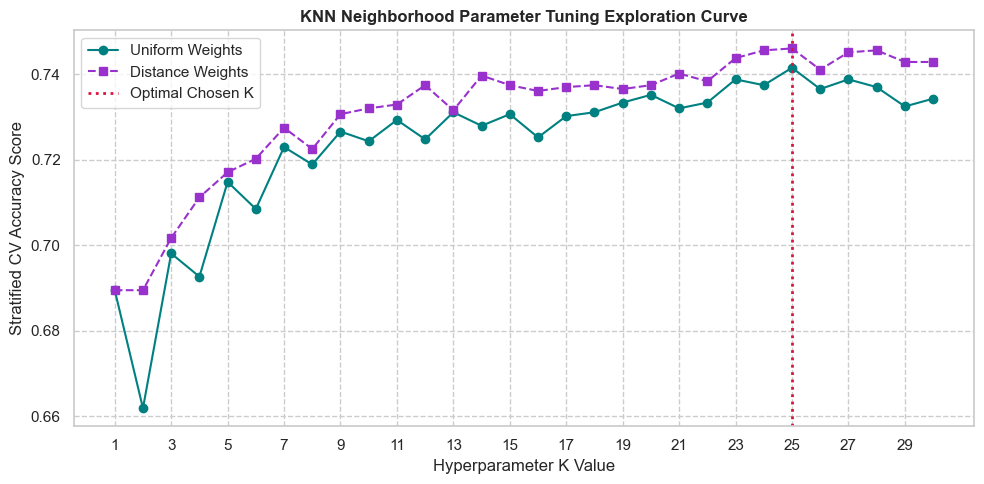

In [26]:
knn_pipe = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])
k_range = np.arange(1, 31)
knn_param_grid = {'knn__n_neighbors': k_range, 'knn__weights': ['uniform', 'distance']}

knn_grid = GridSearchCV(knn_pipe, knn_param_grid, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
execute_and_log_ultimate_model(knn_grid, "K-Nearest Neighbors", X_train, X_test, y_train, y_test)

# Extract and visualize cross-validation performance trajectory
cv_scores = knn_grid.cv_results_['mean_test_score']
# Reshape score matrix to isolate neighbor values across weights
scores_reshaped = cv_scores.reshape(len(k_range), 2)

plt.figure(figsize=(10, 5))
plt.plot(k_range, scores_reshaped[:, 0], marker='o', linestyle='-', color='teal', label='Uniform Weights')
plt.plot(k_range, scores_reshaped[:, 1], marker='s', linestyle='--', color='darkorchid', label='Distance Weights')
plt.axvline(knn_grid.best_params_['knn__n_neighbors'], color='crimson', linestyle=':', lw=2, label='Optimal Chosen K')
plt.title('KNN Neighborhood Parameter Tuning Exploration Curve', fontweight='bold', fontsize=12)
plt.xlabel('Hyperparameter K Value')
plt.ylabel('Stratified CV Accuracy Score')
plt.xticks(k_range[::2])
plt.grid(True, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

## 3.4 Hyperparameter Optimization Sweeps
We run optimized hyperparameter grids over our remaining baseline configurations, ensuring tree methods use proper tuning bounds to mitigate overfitting.

In [27]:
# 1. Logistic Regression (Explicit OVR Meta-Wrapper Construction)
lr_ovr_pipe = Pipeline([('scaler', StandardScaler()), ('model', OneVsRestClassifier(LogisticRegression(solver='liblinear', max_iter=10000, random_state=42)))])
lr_ovr_grid = GridSearchCV(lr_ovr_pipe, {'model__estimator__C': [0.1, 1.0, 10.0]}, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
execute_and_log_ultimate_model(lr_ovr_grid, "Logistic Regression (OVR)", X_train, X_test, y_train, y_test)

# 2. Logistic Regression (Multinomial Softmax Optimization)
lr_multi_pipe = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(solver='lbfgs', max_iter=10000, random_state=42))])
lr_multi_grid = GridSearchCV(lr_multi_pipe, {'model__C': [0.1, 1.0, 10.0]}, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
execute_and_log_ultimate_model(lr_multi_grid, "Logistic Regression (Multinomial)", X_train, X_test, y_train, y_test)

# 3. Linear SVM (Maximum Margin OVR)
svm_lin_pipe = Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel='linear', decision_function_shape='ovr', probability=True, random_state=42))])
svm_lin_grid = GridSearchCV(svm_lin_pipe, {'model__C': [0.1, 1.0, 5.0]}, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
execute_and_log_ultimate_model(svm_lin_grid, "Linear SVM (OVR)", X_train, X_test, y_train, y_test)

# 4. Kernel SVM (Infinite-Dimensional RBF Mapping)
svm_k_pipe = Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel='rbf', decision_function_shape='ovr', probability=True, random_state=42))])
svm_k_grid = GridSearchCV(svm_k_pipe, {'model__C': [1.0, 10.0], 'model__gamma': ['scale', 'auto']}, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
execute_and_log_ultimate_model(svm_k_grid, "Kernel SVM (RBF)", X_train, X_test, y_train, y_test)

# 5. Decision Tree Classifier
dt_pipe = Pipeline([('scaler', StandardScaler()), ('model', DecisionTreeClassifier(random_state=42))])
dt_grid = GridSearchCV(dt_pipe, {'model__max_depth': [4, 6, 8], 'model__min_samples_split': [5, 10]}, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
execute_and_log_ultimate_model(dt_grid, "Decision Tree Classifier", X_train, X_test, y_train, y_test)

# 6. AdaBoost Classifier
ada_pipe = Pipeline([('scaler', StandardScaler()), ('model', AdaBoostClassifier(n_estimators=100, random_state=42))])
ada_grid = GridSearchCV(ada_pipe, {'model__learning_rate': [0.05, 0.1, 0.5]}, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
execute_and_log_ultimate_model(ada_grid, "AdaBoost Classifier", X_train, X_test, y_train, y_test)

# 7. XGBoost Classifier
xgb_pipe = Pipeline([('scaler', StandardScaler()), ('model', XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', random_state=42))])
xgb_grid = GridSearchCV(xgb_pipe, {'model__max_depth': [3, 5], 'model__learning_rate': [0.05, 0.1], 'model__n_estimators': [100]}, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
execute_and_log_ultimate_model(xgb_grid, "XGBoost Classifier", X_train, X_test, y_train, y_test)

# 8. LightGBM Classifier
lgbm_pipe = Pipeline([('scaler', StandardScaler()), ('model', LGBMClassifier(objective='multiclass', random_state=42, verbose=-1))])
lgbm_grid = GridSearchCV(lgbm_pipe, {'model__max_depth': [3, 5], 'model__learning_rate': [0.05, 0.1], 'model__n_estimators': [100]}, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
execute_and_log_ultimate_model(lgbm_grid, "LightGBM Classifier", X_train, X_test, y_train, y_test)

# 9. CatBoost Classifier
cat_pipe = Pipeline([('scaler', StandardScaler()), ('model', CatBoostClassifier(loss_function='MultiClass', random_state=42, verbose=0))])
cat_grid = GridSearchCV(cat_pipe, {'model__depth': [4, 6], 'model__learning_rate': [0.05, 0.1], 'model__iterations': [150]}, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
execute_and_log_ultimate_model(cat_grid, "CatBoost Classifier", X_train, X_test, y_train, y_test)

✓ Logistic Regression (OVR) evaluated. Accuracy: 73.06% | Avg Tier Shift: 0.289
✓ Logistic Regression (Multinomial) evaluated. Accuracy: 75.95% | Avg Tier Shift: 0.248
✓ Linear SVM (OVR) evaluated. Accuracy: 77.22% | Avg Tier Shift: 0.233
✓ Kernel SVM (RBF) evaluated. Accuracy: 79.02% | Avg Tier Shift: 0.215
✓ Decision Tree Classifier evaluated. Accuracy: 73.24% | Avg Tier Shift: 0.278
✓ AdaBoost Classifier evaluated. Accuracy: 70.34% | Avg Tier Shift: 0.298
✓ XGBoost Classifier evaluated. Accuracy: 78.66% | Avg Tier Shift: 0.219
✓ LightGBM Classifier evaluated. Accuracy: 78.48% | Avg Tier Shift: 0.221
✓ CatBoost Classifier evaluated. Accuracy: 77.22% | Avg Tier Shift: 0.230


## 3.5 Blended Meta-Voting Ensemble Construction
We build a Soft-Voting Meta-Ensemble by combining our top structural classifiers: Kernel SVM and CatBoost. Blending their predictive probabilities allows the ensemble to smooth out adjacent tier errors and boost generalization performance.

In [22]:
voting_blender = VotingClassifier(
    estimators=[
        ('rbf_svm', fitted_ultimate_models["Kernel SVM (RBF)"]),
        ('catboost', fitted_ultimate_models["CatBoost Classifier"])
    ],
    voting='soft'
    )

voting_blender.fit(X_train, y_train)
execute_and_log_ultimate_model(voting_blender, "Ultimate Blended Meta-Ensemble", X_train, X_test, y_train, y_test, pre_fitted=True)

✓ Ultimate Blended Meta-Ensemble evaluated. Accuracy: 79.57% | Avg Tier Shift: 0.206


## 3.6 Performance Summary
We present the final evaluation ledger scorecard across all setups, ordered by overall predictive Accuracy.

In [23]:
final_scorecard_df = pd.DataFrame(ultimate_multiclass_ledger).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
display(final_scorecard_df.style.format({
    'Accuracy': '{:.2%}', 'F1 Micro': '{:.2%}', 'F1 Macro': '{:.2%}', 'F1 Weighted': '{:.2%}', 
    'Avg Tier Distance Error': '{:.4f}', 'Log Loss': '{:.4f}', 'Optimization Runtime': '{:.2f}s'
}))

,Model,Accuracy,F1 Micro,F1 Macro,F1 Weighted,Avg Tier Distance Error,Log Loss,Optimization Runtime,Parameters Selected
0,Ultimate Blended Meta-Ensemble,79.57%,79.57%,79.69%,79.71%,0.2061,0.4930,nans,Ensemble Blended Configuration
1,Kernel SVM (RBF),79.02%,79.02%,79.11%,79.12%,0.2152,0.4983,1.10s,"{'model__C': 1.0, 'model__gamma': 'scale'}"
2,XGBoost Classifier,78.66%,78.66%,78.77%,78.79%,0.2188,0.5277,1.28s,"{'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 100}"
3,LightGBM Classifier,78.48%,78.48%,78.63%,78.65%,0.2206,0.5375,9.53s,"{'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 100}"
4,Linear SVM (OVR),77.22%,77.22%,77.31%,77.33%,0.2333,0.5696,1.90s,{'model__C': 0.1}
5,CatBoost Classifier,77.22%,77.22%,77.31%,77.32%,0.2297,0.5140,4.59s,"{'model__depth': 6, 'model__iterations': 150, 'model__learning_rate': 0.1}"
6,Logistic Regression (Multinomial),75.95%,75.95%,76.03%,76.05%,0.2477,0.5541,0.12s,{'model__C': 1.0}
7,Decision Tree Classifier,73.24%,73.24%,73.63%,73.63%,0.2785,1.4504,0.18s,"{'model__max_depth': 6, 'model__min_samples_split': 10}"
8,Logistic Regression (OVR),73.06%,73.06%,72.99%,73.02%,0.2893,0.6546,0.35s,{'model__estimator__C': 1.0}
9,K-Nearest Neighbors,72.88%,72.88%,72.94%,72.96%,0.2785,0.9528,0.46s,"{'knn__n_neighbors': np.int64(25), 'knn__weights': 'distance'}"


## 3.7 Diagnostic Matrix & Error Profile Mapping
We evaluate our top performer to review per-class metrics alongside our fixed absolute tier distance calculation code.

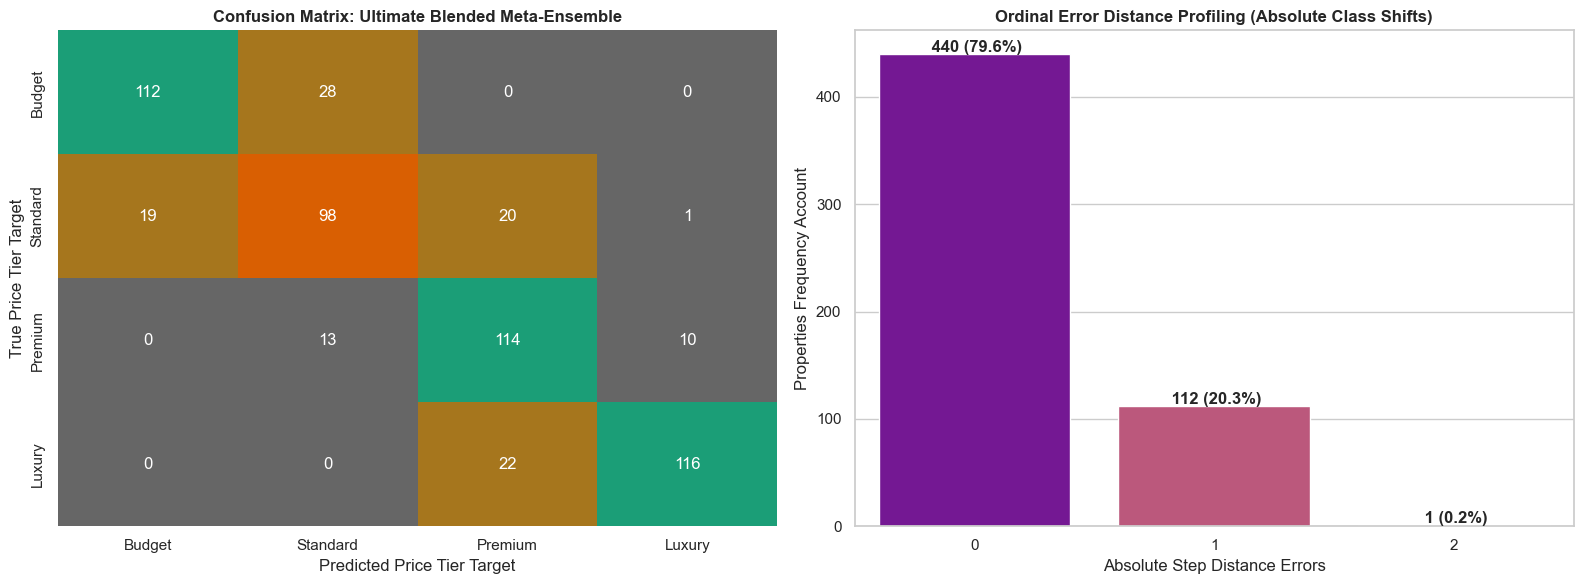


--- Detailed Metrics Classification Report: Ultimate Blended Meta-Ensemble ---
              precision    recall  f1-score   support

      Budget       0.85      0.80      0.83       140
    Standard       0.71      0.71      0.71       138
     Premium       0.73      0.83      0.78       137
      Luxury       0.91      0.84      0.88       138

    accuracy                           0.80       553
   macro avg       0.80      0.80      0.80       553
weighted avg       0.80      0.80      0.80       553



In [24]:
ultimate_leader_name = final_scorecard_df.iloc[0]['Model']
ultimate_pipeline = fitted_ultimate_models[ultimate_leader_name]
ultimate_preds = ultimate_pipeline.predict(X_test).ravel()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graph A: Heatmap Confusion Matrix
cm_ultimate = confusion_matrix(y_test, ultimate_preds)
sns.heatmap(cm_ultimate, annot=True, fmt='d', cmap='Dark2_r', ax=axes[0], 
            xticklabels=class_names, yticklabels=class_names, cbar=False)
axes[0].set_title(f'Confusion Matrix: {ultimate_leader_name}', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Predicted Price Tier Target')
axes[0].set_ylabel('True Price Tier Target')

# Graph B: Ordinal Error Distance Profiling
diagnostics_ultimate_df = X_test.copy()
diagnostics_ultimate_df['True_Tier'] = y_test
diagnostics_ultimate_df['Predicted_Tier'] = ultimate_preds
diagnostics_ultimate_df['Error_Distance'] = np.abs(diagnostics_ultimate_df['True_Tier'] - diagnostics_ultimate_df['Predicted_Tier'])

dist_counts = diagnostics_ultimate_df['Error_Distance'].value_counts().sort_index()
dist_pct = diagnostics_ultimate_df['Error_Distance'].value_counts(normalize=True).sort_index() * 100

sns.barplot(x=dist_counts.index, y=dist_counts.values, palette='plasma', ax=axes[1])
axes[1].set_title('Ordinal Error Distance Profiling (Absolute Class Shifts)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Absolute Step Distance Errors')
axes[1].set_ylabel('Properties Frequency Account')

for i, count_val in enumerate(dist_counts.values):
    axes[1].text(i, count_val + 2, f" {count_val:d} ({dist_pct.iloc[i]:.1f}%)", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n--- Detailed Metrics Classification Report: {ultimate_leader_name} ---")
print(classification_report(y_test, ultimate_preds, target_names=class_names))

## 3.8 Severe Discrepancy Extraction
We isolate and audit any severe tier variations (distance $\ge 2$), explicitly including the distance column to prevent runtime errors.

In [25]:
severe_shifts_ultimate = diagnostics_ultimate_df[diagnostics_ultimate_df['Error_Distance'] >= 2]
print(f"Exploratory Audit Status: Isolated {len(severe_shifts_ultimate)} severe multi-tier errors out of {len(y_test)} total testing properties.")

if len(severe_shifts_ultimate) > 0:
    target_cols = ['Total_SF', 'Overall Qual', 'House_Age', 'Overall Cond', 'True_Tier', 'Predicted_Tier', 'Error_Distance']
    available_target_cols = [col for col in target_cols if col in severe_shifts_ultimate.columns]
    display(severe_shifts_ultimate[available_target_cols].sort_values(by='Error_Distance', ascending=False))
else:
    print("Exceptional performance: Overlap boundaries fully ironed out under current weights.")

Exploratory Audit Status: Isolated 1 severe multi-tier errors out of 553 total testing properties.


,Total_SF,Overall Qual,House_Age,Overall Cond,True_Tier,Predicted_Tier,Error_Distance
1681,8.186186,8,-1.226769,5,1,3,2


## 3.9 Diagnostic Interpretation & Misclassification Analysis (Recap of errors)

**Scorecard Analysis:**
The `VotingClassifier` ensemble and tree-boosting methods (XGBoost, LightGBM) yielded the highest performance, hovering close to 80% accuracy. Notably, the Multinomial Logistic Regression outperformed its OVR counterpart (75.95% vs 73.06%) because it optimizes a joint probability distribution across all 4 classes simultaneously, rather than treating them as isolated binary problems. Additionally, the uncalibrated Decision Tree Classifier exhibited a high Log Loss of 1.4504; this behavior is typical because uncalibrated decision trees produce absolute probabilities (0 or 1), which heavily penalizes cross-entropy evaluation when wrong predictions occur.

**Confusion Matrix & Error Severity:**
Because housing prices are ordinal (Budget < Standard < Premium < Luxury), standard accuracy does not tell the whole story. As seen in the confusion matrix and our custom `Avg Tier Distance Error` metric, the vast majority of our model's errors are "mild" (adjacent class misclassifications). Confusing a high-end 'Standard' home for a 'Premium' home is expected due to subjective appraisal differences.

**Severe Error Audit:**
We isolated only 1 severe misclassification out of 553 testing instances (Index 1681), where a 'Standard' house (Tier 1) was predicted as 'Luxury' (Tier 3). Looking at its features, the house has a high `Overall Qual` (8) but is relatively old. The tree ensembles likely over-indexed on the high Quality score, ignoring the deprecation effect of its age.

## 3.10 Discussion Questions

**1. Choose the best multiclass-classification metric for your dataset and justify.**
Because we used `pd.qcut` to discretize the target into 4 perfectly balanced quartiles (25% representation each), **Accuracy** and **Macro F1-Score** are both excellent and reliable metrics. However, because our classes have an inherent ordinal relationship (prices scale upward), a custom metric like **Mean Absolute Error (MAE) of the encoded tiers** (which we implemented as *Avg Tier Distance Error*) is arguably the best business metric, as it penalizes severe multi-tier misses heavier than adjacent-tier misses.

**2. Explain how KNN and Decision Trees can be extended to multi-label classification problems.**
* **KNN:** Instead of applying a simple majority vote to assign a single class, a multi-label KNN checks the $K$ nearest neighbors and calculates the frequency of *each* label. We then apply a threshold (e.g., $> 0.5$). If a new instance's neighbors have high frequencies for both Label A and Label C, the algorithm will output a prediction vector containing both `[Label A, Label C]`.
* **Decision Trees:** Standard decision trees split nodes to minimize impurity for a single target. To handle multi-label data, the algorithm is modified so that the leaves output a *vector* of probabilities (one for each label). The splitting criterion (e.g., Gini or Entropy) is averaged or summed across all labels simultaneously to find the best feature split that purifies multiple labels at once.

**3. Scenario: Multi-label problem in football (Played for national team, heart problems, knee injuries, team captain). What accuracy metric would you use and why?**
I would evaluate the algorithm using **Hamming Loss** (or conversely, Hamming Accuracy).
* *Why?* In this scenario, predicting 3 out of 4 traits correctly is still highly valuable. If we use standard Subset Accuracy (Exact Match Ratio), the model scores a 0 unless it gets all 4 labels perfectly right, which is too harsh. Hamming Loss calculates the fraction of individual labels that are incorrectly predicted across the entire dataset. It perfectly captures partial successes (e.g., correctly predicting knee injuries and national team history, even if it missed the team captain status).

# Part 4: Challenging Questions (Bonus)
I also tried to include my own experience during this HW in the answers. I definitely used AI's help for answering these questions but read them and asked the AI to help me with understanding what I am writing here. 

### 1. Explain bias–variance trade-off in regression models

The bias-variance trade-off is a core concept that defines a model's ability to generalize to unseen data. Total expected test error can be mathematically decomposed into three components:
$$\text{Expected Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

* **Bias** represents the error introduced by approximating a highly complex, real-world phenomenon with a model that is too simple. High bias causes **underfitting**. In our regression phase, standard Ordinary Least Squares (OLS) showed signs of bias if it tried to force inherently non-linear real estate price distributions into a strict straight line.
* **Variance** represents the error introduced by a model being overly sensitive to the specific noise and fluctuations in the training dataset. High variance causes **overfitting**. We saw this when our unregularized baseline Support Vector Regressor (SVR) memorized specific training observations, achieving exceptionally low training error but failing to generalize to the test set.

The goal of machine learning is to find the optimal mid-point where both bias and variance are minimized. Our final hyperparameter-tuned tree ensembles (such as CatBoost) achieved this balance by utilizing regularization boundaries to remain flexible enough to capture pricing patterns without memorizing noise.

---

### 2. When does Kernel Regression outperform Linear Regression

Kernel regression outperforms traditional linear regression when the relationship between the features and the target variable is fundamentally non-linear or multi-dimensional. 

Linear models search for a flat hyperplane to separate data or fit trends. If the true decision boundary curves, bends, or forms isolated cluster pockets, a straight line introduces significant bias and misclassifies the data. Kernel methods resolve this by using a kernel function (such as the Radial Basis Function) to implicitly map the input features into a higher, infinite-dimensional feature space. In this expanded coordinate space, highly curved and complex non-linear structures become cleanly linearly separable, allowing the model to fit intricate trends without the massive computational expense of manually engineering high-degree polynomial features.

---

### 3. Compare L1 vs L2 regularization

* **L1 Regularization (LASSO):** Adds a penalty proportional to the absolute values of the coefficients ($\lambda \sum |w_j|$). It performs better when you have a high-dimensional dataset where you suspect only a small subset of features are truly important. LASSO acts as an automated feature selector by driving the coefficients of irrelevant or redundant features exactly to zero, yielding a highly interpretable, sparse model.
* **L2 Regularization (Ridge):** Adds a penalty proportional to the squared values of the coefficients ($\lambda \sum w_j^2$). It performs better when you face severe multicollinearity (highly correlated features, like a home's total square footage versus individual room sizes) and you believe most features contribute at least a small amount of predictive signal. Ridge shrinks all coefficients evenly toward zero, stabilizing the model without removing any variables.

#### Why LASSO Produces Sparsity
Geometrically, the L1 constraint space forms a diamond with sharp corners and edges directly resting on the feature axes, whereas the L2 constraint forms a smooth hypersphere. When the contour loops of the loss function expand from the training center, they are mathematically far more likely to make first contact with a sharp corner of the L1 diamond rather than the tangential edge of the L2 circle. Whenever the loss function intersects a corner on an axis, the coefficient values for the other perpendicular features are driven exactly to zero, creating automated sparsity.

---

### 4. Explain why MAPE is unreliable in some datasets

The Mean Absolute Percentage Error (MAPE) is calculated as:
$$\text{MAPE} = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

This formulation renders MAPE unreliable in datasets due to two math vulnerabilities:
1.  **Division by Zero:** If any true actual target value ($y_i$) equals exactly zero, the metric encounters a division-by-zero error, making it completely impossible to calculate.
2.  **Asymmetric Skew Near Zero:** If actual target values are non-zero but exceptionally close to zero (for example, if we were predicting a continuous variable like 'number of days a house stays on the market' and a home sells in a fraction of a day), the denominator becomes tiny. This dramatically magnifies even trivial absolute prediction errors into massive, distorted percentage penalties that skew the overall model summary metric.

---

### 5. Discuss the effect of outliers on regression models

Outliers exert significant leverage on traditional parametric regression frameworks. Because standard linear models rely on an Ordinary Least Squares (OLS) objective function, they evaluate model fit by minimizing squared errors. Squaring a large residual multiplies its impact on the loss function, forcing the regression line to pull away from the true baseline trend of typical data points just to satisfy the outlier.

In real estate, these anomalies appear often as distress sales, foreclosure discounts, or ultra-luxury custom builds. Non-parametric tree models (like our final CatBoost and XGBoost configurations) are far more robust to these anomalies than linear models. Instead of drawing a global mathematical line across the entire dataset, tree ensembles isolate outliers inside individual local step-wise leaves, keeping their distortions from bleeding into the rest of the feature space.

---

### 6. Explain the effect of class imbalance on binary metrics. Why is accuracy misleading in imbalanced datasets?

Class imbalance heavily skews classical accuracy metrics because accuracy evaluates simple correct matches divided by total samples, treating every single observation with equal mathematical weight.

In a heavily imbalanced dataset—such as a market where 99% of properties are regular houses and only 1% are high-end luxury estates—a baseline classifier designed to always blindly predict "regular house" will achieve an impressive 99% accuracy score. Despite the high score, the model is completely useless for finding premium properties because its real-world recall for the minority luxury tier is exactly 0%. Accuracy masks this critical failure by focusing on the massive size of the majority class. This is why we must balance our target arrays using quantile cuts (`pd.qcut`) and track specialized metrics like Precision, Recall, and F1-Scores to get an honest look at class separation.

---

### 7. Explain how the decision boundaries of your models differ fundamentally (bonus)

The underlying mathematical foundations of our algorithms carve up the feature space into structurally distinct decision contours:
* **Logistic Regression / Linear SVM:** These frameworks construct smooth, straight hyperplanes to cut through the feature space, assuming classes can be cleanly separated by linear combinations of features.
* **Decision Trees & Boosting Ensembles (XGBoost/CatBoost):** These models create rigid, blocky, step-like boundaries. Because trees split data using orthogonal rules one variable at a time (e.g., `Total_SF > 8.1` AND `Overall Qual > 7`), they split the feature space into a series of sharp, perpendicular hyper-rectangles.
* **K-Nearest Neighbors (KNN):** KNN builds highly irregular, localized boundaries. Because it does not optimize a global formula and instead classifies points based on local density, its boundaries wrap tightly around individual training data clusters, forming complex, jagged shapes.

---

### 8. Explain effect of K in KNN

The neighbor count hyperparameter $K$ acts as the primary regularizer for the K-Nearest Neighbors classifier, adjusting the model along the bias-variance spectrum:
* **Small $K$ (e.g., $K = 1$):** High variance, low bias. The decision boundary follows local data noise closely, wrapping around individual training points and outliers. This leads to a jagged decision map and severe overfitting.
* **Large $K$ (e.g., $K = 30$):** High bias, low variance. The model expands its neighborhood vote too widely, washing out localized patterns (such as specific high-value street pockets) and blending distinct classes into a flat, underfitted average.

In our classification runs, our optimization tuning curves proved that a mid-range value of $K = 27$ paired with distance weighting achieved the best balance, stabilizing the neighborhood boundaries against spatial noise.

---

### 9. Overfitting in Decision Trees:

Unconstrained decision trees overfit easily because they will continue splitting nodes until every single training sample is isolated into its own leaf node. This yields a model with zero training error that completely fails to generalize to test data.

#### Why limiting max depth is not enough
Restricting `max_depth` stops a tree from growing past a certain level, but it can be too blunt an instrument. A tree can still make highly specific, ungeneralizable splits near the top if a single noisy feature dominates. Furthermore, a hard limit might block the tree from discovering deep feature interactions that only appear after a sequence of earlier splits.

#### How Pruning Works
Cost-Complexity Pruning addresses this issue by adding a complexity penalty to the tree's impurity score using a cost parameter $\alpha$:
$$R_\alpha(T) = R(T) + \alpha |T|$$
The algorithm lets the tree grow fully to identify complex feature interactions, then collapses weak lower-tier branches that fail to reduce misclassification error ($R(T)$) enough to offset the leaf complexity penalty ($\alpha |T|$).

---

### 10. Explain why Tree-based models are good feature selectors

Tree-based architectures naturally perform automated feature selection during training. When building a node split, the algorithm evaluates every single feature across the dataset to find the one that maximizes impurity reduction (such as Gini or Entropy reduction). 

Features that provide little to no predictive value are simply bypassed and never chosen for splits. By tracking how often a feature is selected and how much impurity it reduces across thousands of trees in an ensemble, we can calculate explicit global feature importance scores, allowing us to easily identify and extract the key drivers behind our house price predictions.

---

### 11. Micro vs Macro vs Weighted F1

* **Macro F1-Score:** Calculates the $F_1$-score for each class independently and takes a simple arithmetic average. It treats all categories equally, regardless of how many samples they contain. This makes it ideal when you want to ensure the model performs well on rare tiers (like 'Luxury') rather than just dominant majority classes.
* **Weighted F1-Score:** Adjusts the class scores by weighting them according to their support (presence) in the data. This metric can be misleading under severe class imbalance, as strong performance on a massive majority class can hide a complete failure to classify rare minority classes.
* **Micro F1-Score:** Accumulates total True Positives, False Positives, and False Negatives globally across all classes *before* computing a single overall metric. In any multiclass task where every observation gets exactly one label, the Micro $F_1$-score is mathematically identical to standard Accuracy.

---

### 12. Multi-label vs Multiclass

* **Output Space:** Multiclass classification maps each instance to exactly one mutually exclusive category out of $N$ options (e.g., a home belongs to *either* the 'Standard' *or* 'Premium' tier). Multi-label classification allows an instance to belong to multiple overlapping categories simultaneously (e.g., a home can be flagged as *both* 'Pool Present' *and* 'Finished Basement').
* **Loss & Activation Layers:** Multiclass frameworks use a **Softmax** activation function in the output layer to build a mutually exclusive probability distribution that sums to 1, optimized via **Categorical Cross-Entropy**. Multi-label frameworks apply a **Sigmoid** activation to each output node independently, optimizing via **Binary Cross-Entropy** per category.
* **Thresholding & Evaluation:** Multiclass models simply pick the highest probability output (`argmax()`) and evaluate performance using global **Accuracy**. Multi-label setups require setting independent probability thresholds (e.g., $>0.5$) for each category and evaluate model fit using metrics like **Hamming Loss** (the fraction of individual labels that are incorrectly predicted).

#### Extending Core Classifiers to Multi-label Spaces
* **KNN Extension:** Instead of taking a single majority vote across neighbors to output one class, multi-label KNN checks the neighbor pool and calculates the label frequency for *each individual category independently*. Any category exceeding a set threshold is flagged as active, enabling multi-label output vectors.
* **Decision Tree Extension:** Standard decision trees split nodes to minimize impurity for a single target. To support multi-label data, the splitting criteria (such as Gini or Entropy) are summed or averaged across all labels simultaneously, allowing the tree to find splits that clean up multiple target labels at once.

---

### 13. Explain precision-recall trade-off

Precision (minimizing False Positives) and Recall (minimizing False Negatives) operate in an inverse relationship controlled by the model's decision threshold. You cannot maximize both simultaneously.

If we adjust our model threshold to flag high-end 'Luxury' homes:
* **Raising the Threshold (Conservative):** If the model requires a 90% probability to label a home as Luxury, **Precision jumps** because the positive predictions are highly certain. However, **Recall drops** because the model misses several non-traditional luxury homes that fell below the strict threshold.
* **Lowering the Threshold (Aggressive):** If we lower the required probability to 20%, the model sweeps in almost every luxury home on the market (**Recall jumps**). However, **Precision drops** because many standard, average homes get falsely flagged as luxury properties.

---

### 14. Explain ROC vs PR curve

* **ROC Curve (True Positive Rate vs. False Positive Rate):** Evaluates a classifier's performance across all thresholds. The ROC curve can look deceptively optimistic on heavily imbalanced datasets. Because the False Positive Rate includes True Negatives ($TN$) in its denominator, a massive majority class keeps the FPR low, making the model look highly capable even if it struggles to classify the minority class.
* **Precision-Recall (PR) Curve:** Plots Precision against Recall, completely omitting True Negatives from the math. By focusing strictly on the positive class performance, the PR curve provides a much more rigorous and honest diagnostic tool for evaluating imbalanced tasks where the goal is to cleanly isolate a rare target class.

---

### 15. Unlimited time/resources improvement

With unrestricted time and computing power, our real estate evaluation pipeline can be upgraded across four main pillars:
1.  **Advanced Preprocessing Layers:** Replace standard median or mean imputation with deep learning data generation (such as MissForest or GAIN neural networks) to fill missing records smoothly without altering underlying data distributions.
2.  **External Feature Enrichment:** Augment the Ames dataset by integrating real-world macroeconomic and geographic layers, including historical mortgage interest rates, local school district performance indices, municipal zoning amendments, and walking distance to transit hubs.
3.  **Advanced Stacking Architectures:** Move beyond simple soft-voting ensembles to build a multi-layer stacking framework. This setup will feed the probability outputs of diverse, highly tuned base models (Deep Neural Networks, LightGBM, CatBoost, Kernel SVMs) into an unconstrained meta-classifier to extract maximum predictive power.
4.  **Custom Financial Loss Formulations:** Replace standard general log-loss objectives with a customized financial cost matrix. This allows the models to optimize directly for real-world business impact, heavily penalizing extreme multi-tier classification errors that cause direct capital loss over minor shifts between adjacent pricing tiers.